In [1]:
from scipy.signal import find_peaks
from astropy.io import fits
from specutils import Spectrum1D
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
import requests
from io import BytesIO
import os
import csv


In [2]:
def inject_and_plot_laser(obj_id, filt, folder="/datax/scratch/emmay/galah_spectra",
                          fwhm=1.5, laser_amp_percent=20, plot=True):
    """
    Injects a Gaussian laser spike into GALAH FITS spectrum and plots it.

    Parameters:
        obj_id (str): Object ID
        filt (str): Filter (e.g. 'B', 'V', 'R', 'I')
        folder (str): Path to FITS files
        fwhm (float): FWHM of the Gaussian in pixels
        laser_amp_percent (float): Amplitude of injection as percentage of max flux
        plot (bool): Whether to show the plot

    Returns:
        wavelength (np.ndarray): Wavelength array (in Å)
        flux_injected (np.ndarray): Flux array with injected Gaussian
    """
    filename = f"{obj_id}_{filt}.fits"
    path = os.path.join(folder, filename)

    with fits.open(path) as hdul:
        header = hdul[1].header
        flux = hdul[1].data.astype(float)

    # Build wavelength axis
    crval1 = header.get('CRVAL1')
    cdelt1 = header.get('CDELT1')
    crpix1 = header.get('CRPIX1', 1)

    npix = len(flux)
    wavelength = (crval1 + (np.arange(npix) + 1 - crpix1) * cdelt1) * u.AA

    # Inject Gaussian
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    center = npix // 2
    x = np.arange(npix)
    gaussian = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    gaussian *= (laser_amp_percent / 100.0) * np.nanmax(flux)

    flux_injected = flux + gaussian

    # Plot
    if plot:
        threshold_mask = gaussian > 1e-4
        plt.figure(figsize=(13, 5))
        plt.plot(wavelength, flux, color='blue', linewidth=0.6, label="Original Spectrum")
        plt.plot(wavelength[threshold_mask], flux_injected[threshold_mask], color='red', linewidth=1.0, label="Injected Region")
        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")
        plt.title(f"Injected Spectrum — {obj_id} ({filt}) — Amplitude = {laser_amp_percent}%")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return wavelength.value, flux, flux_injected, wavelength[center]


In [3]:
# Mean pixel scales and starting wavelengths from header survey
BAND_CDELT1 = {
    "B": 0.046001,
    "V": 0.054688,
    "R": 0.063128,
    "I": 0.073557,
}

BAND_CRVAL1 = {
    "B": 4713.460743,
    "V": 5648.643181,
    "R": 6478.092568,
    "I": 7585.251283,
}

def get_flux_wl(obj_id, filt, folder="/datax/scratch/emmay/galah_spectra"):
    """
    Reads a GALAH FITS spectrum and returns the wavelength and flux arrays,
    using band-mean CDELT1 and CRVAL1 values in place of per-file header values.

    Parameters:
        obj_id (str): Object ID
        filt (str): Filter ('B', 'V', 'R', 'I')
        folder (str): Path to FITS files

    Returns:
        wavelength (np.ndarray): Wavelength array (in Å), unitless
        flux (np.ndarray): Flux array
    """
    filename = f"{obj_id}_{filt}.fits"
    path = os.path.join(folder, filename)

    with fits.open(path) as hdul:
        header = hdul[1].header
        flux = hdul[1].data.astype(float)
        npix = header.get('NAXIS1', len(flux))  # prefer header value

    # Use band-mean values instead of per-file header (which has small scatter)
    crval1 = BAND_CRVAL1[filt]
    cdelt1 = BAND_CDELT1[filt]

    wavelength = crval1 + np.arange(npix) * cdelt1  # CRPIX1=1, so pixel 0 = CRVAL1

    return wavelength, flux

## Find Peak

In [4]:

def measure_width_at_y(flux, wavelength, peak_idx, y_level=1):
    """Measure width of a peak at a fixed y_level using linear interpolation."""
    # Left side
    i = peak_idx
    while i > 0 and flux[i] > y_level:
        i -= 1
    if i == 0 or flux[i] > y_level:
        return None  # No valid left edge
    left = wavelength[i] + (y_level - flux[i]) / (flux[i+1] - flux[i]) * (wavelength[i+1] - wavelength[i])

    # Right side
    i = peak_idx
    while i < len(flux) - 1 and flux[i] > y_level:
        i += 1
    if i == len(flux) - 1 or flux[i] > y_level:
        return None  # No valid right edge
    right = wavelength[i-1] + (y_level - flux[i-1]) / (flux[i] - flux[i-1]) * (wavelength[i] - wavelength[i-1])

    return left, right, right - left

In [5]:
def detect_laser_peak_with_fixed_level_width(
    wavelength, 
    flux, 
    height_fraction=0.2, # changed to be an absolute number, not percentage of max flux, threshold = 1+height_fraction
    y_level=1.0, 
    max_pixel_width=3,
    injected_wavelength=None,
    plot=True
):
    flux = np.asarray(flux)
    wavelength = np.asarray(wavelength)

    # Height threshold: fraction of max flux above continuum (assumed ~1)
    height_threshold = 1 + height_fraction #* np.nanmax(np.abs(flux - 1))
    peak_indices, properties = find_peaks(flux, height=height_threshold)

    if len(peak_indices) == 0:
        if plot:
            plt.figure(figsize=(12, 4))
            plt.plot(wavelength, flux, label="Full Spectrum")
            if injected_wavelength is not None:
                plt.axvline(x=float(injected_wavelength.value), color='r', linestyle='--', linewidth=2, label="Injected Laser")
            plt.xlabel("Wavelength (Å)")
            plt.ylabel("Flux")
            plt.title("Full Spectrum (No Peaks Detected)")
            plt.legend()
            plt.tight_layout()
            plt.show()
        return [], [], []

    peak_wavelengths = []
    peak_fluxes = []
    widths = []
    valid_peak_indices = []

    pixel_scale = np.median(np.diff(wavelength))

    for i, idx in enumerate(peak_indices):
        result = measure_width_at_y(flux, wavelength, idx, y_level=y_level)
        if result is not None:
            left, right, width = result
            width_in_pixels = width / pixel_scale

            if width_in_pixels > max_pixel_width:
                continue

            peak_wavelengths.append(wavelength[idx])
            peak_fluxes.append(flux[idx])
            widths.append(width)
            valid_peak_indices.append(idx)

            if plot:
                i_min = max(0, idx - 20)
                i_max = min(len(wavelength), idx + 20)

                plt.figure(figsize=(10, 4))
                plt.plot(wavelength[i_min:i_max], flux[i_min:i_max], label="Flux")
                plt.axvline(left, color='C2', linestyle='--')
                plt.axvline(right, color='C2', linestyle='--')
                plt.hlines(y_level, left, right, color='C3', linewidth=2, label=f'Width @ y={y_level}')
                plt.plot(wavelength[idx], flux[idx], 'rx', label="Peak Center")
                plt.xlabel("Wavelength (Å)")
                plt.ylabel("Flux")
                plt.title(f"Zoomed Peak at {wavelength[idx]:.2f} Å, Width = {width:.3f} Å ({width_in_pixels:.2f} px)")
                plt.legend()
                plt.tight_layout()
                plt.show()

    if plot and valid_peak_indices:
        plt.figure(figsize=(12, 4))
        plt.plot(wavelength, flux, label="Full Spectrum")
        for idx in valid_peak_indices:
            plt.plot(wavelength[idx], flux[idx], 'rx', label="Detected Peaks")

        if injected_wavelength is not None:
            plt.axvline(x=float(injected_wavelength.value), color='black', linestyle='--', linewidth=2, label="Injected Laser")

        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")
        plt.title("Full Spectrum with Detected Peaks")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return peak_wavelengths, peak_fluxes, widths

## Find Peaks Only Loop for Multiple Objects

In [7]:
import csv
from tqdm import tqdm

folder = "/datax/scratch/emmay/galah_spectra"
fits_files = [f for f in os.listdir(folder) if f.endswith(".fits")]

results = []
errors = []  # collect errors instead of printing them inline

for fits_file in tqdm(fits_files[:4000], desc="Detecting peaks"):
    filename_no_ext = fits_file[:-5]
    obj_id = filename_no_ext[:15]
    filt = filename_no_ext[16:]

    try:
        # Step 1: Read original spectrum (no injection)
        wave, flux = get_flux_wl(obj_id, filt, folder=folder)

        # Step 2: Try to detect peaks
        peak_wavelengths, peak_fluxes, widths = detect_laser_peak_with_fixed_level_width(
            wave, flux, height_fraction=0.15, y_level=1.0, max_pixel_width=5, plot=False
        )

        # Step 3: Save results for each detected peak
        for wl, fl, w in zip(peak_wavelengths, peak_fluxes, widths):
            results.append({
                "obj_id": obj_id,
                "filt": filt,
                "peak_wavelength": wl,
                "peak_flux": fl,
                "peak_width": w
            })

    except Exception as e:
        errors.append((fits_file, str(e)))
        print(str(e))

output_path = os.path.join(folder, "detected_peaks", "noninjected_detected_peaks.csv")
with open(output_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["obj_id", "filt", "peak_wavelength", "peak_flux", "peak_width"])
    writer.writeheader()
    writer.writerows(results)

print(f"Saved {len(results)} detected peaks to {output_path}")
if errors:
    print(f"{len(errors)} files failed (see `errors` list for details)")

Detecting peaks:   0%|          | 0/4000 [00:00<?, ?it/s]

Detecting peaks:   3%|▎         | 118/4000 [00:00<00:16, 238.99it/s]

No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True


Detecting peaks:   6%|▌         | 242/4000 [00:00<00:12, 292.99it/s]

No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True


...

No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True


Detecting peaks:  99%|█████████▉| 3979/4000 [00:12<00:00, 323.07it/s]

No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True
No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True


Detecting peaks: 100%|██████████| 4000/4000 [00:13<00:00, 307.43it/s]


Saved 35278 detected peaks to /datax/scratch/emmay/galah_spectra/detected_peaks/noninjected_detected_peaks.csv
94 files failed (see `errors` list for details)


In [8]:
import pandas as pd
from astropy.io import fits
from tqdm import tqdm

folder = "/datax/scratch/emmay/galah_spectra"
fits_files = [f for f in os.listdir(folder) if f.endswith(".fits")]

header_records = []
errors = []

for fits_file in tqdm(fits_files[:4000], desc="Reading headers"):
    filename_no_ext = fits_file[:-5]
    obj_id = filename_no_ext[:15]
    filt = filename_no_ext[16:]

    try:
        path = os.path.join(folder, fits_file)
        with fits.open(path) as hdul:
            header = hdul[1].header
            cdelt1 = header.get('CDELT1')
            crval1 = header.get('CRVAL1')
            naxis1 = header.get('NAXIS1')

        header_records.append({
            "obj_id": obj_id,
            "filt": filt,
            "CDELT1": cdelt1,   # pixel scale (Å/pix)
            "CRVAL1": crval1,   # starting wavelength (Å)
            "NAXIS1": naxis1,   # number of pixels
        })

    except Exception as e:
        errors.append((fits_file, str(e)))

hdr_df = pd.DataFrame(header_records)

# Summary statistics grouped by filter/band
summary = hdr_df.groupby("filt").agg(
    n_files=("CDELT1", "count"),
    cdelt1_mean=("CDELT1", "mean"),
    cdelt1_std=("CDELT1", "std"),
    cdelt1_min=("CDELT1", "min"),
    cdelt1_max=("CDELT1", "max"),
    crval1_mean=("CRVAL1", "mean"),
    crval1_std=("CRVAL1", "std"),
    naxis1_unique=("NAXIS1", pd.Series.nunique),
).reset_index()

print(summary.to_string(index=False))
print(f"\n{len(errors)} files failed")

Reading headers: 100%|██████████| 4000/4000 [00:11<00:00, 358.04it/s]

filt  n_files  cdelt1_mean  cdelt1_std  cdelt1_min  cdelt1_max  crval1_mean  crval1_std  naxis1_unique
   B      999     0.046001    0.000021    0.045915    0.046048  4713.460743    0.398901              1
   I      909     0.073557    0.000038    0.073447    0.073657  7585.251283    0.590478              1
   R      999     0.063128    0.000033    0.063039    0.063318  6478.092568    0.768635              1
   V      999     0.054688    0.000031    0.054571    0.054791  5648.643181    0.637540              1

94 files failed


# Stats of Noninjected Detections

Loaded 35278 detected peaks


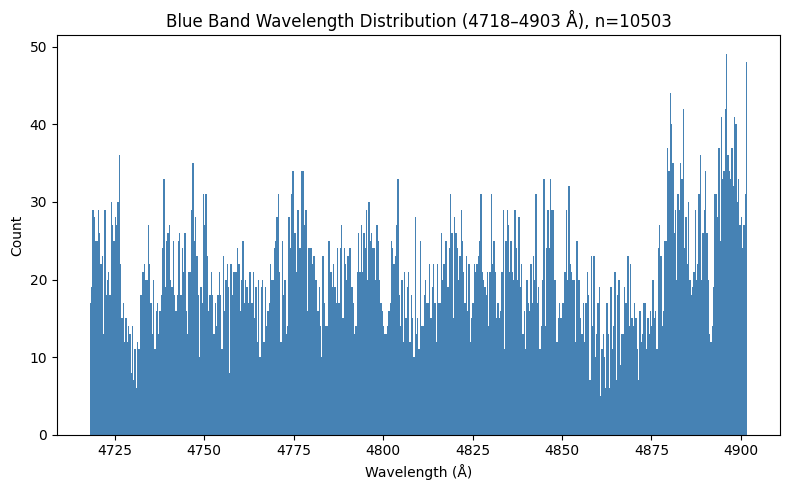

Blue: 10503 detections in range
Blue: 10503 total detections | bins ≥ 3 counts: 37


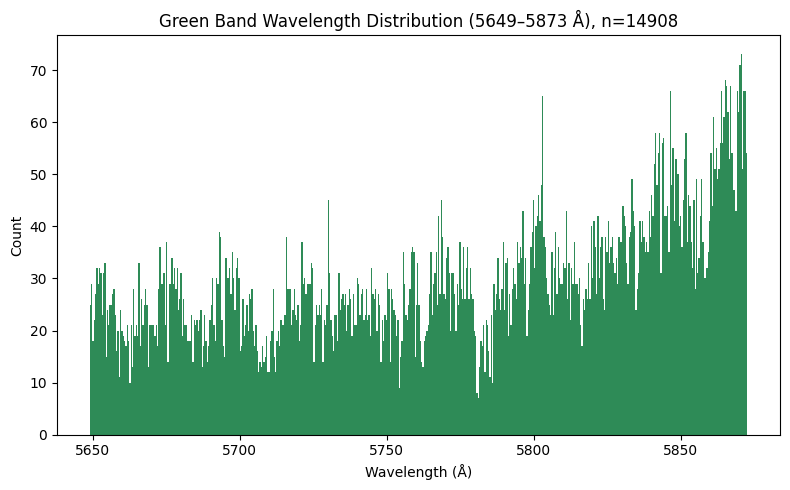

Green: 14908 detections in range
Green: 14908 total detections | bins ≥ 3 counts: 44


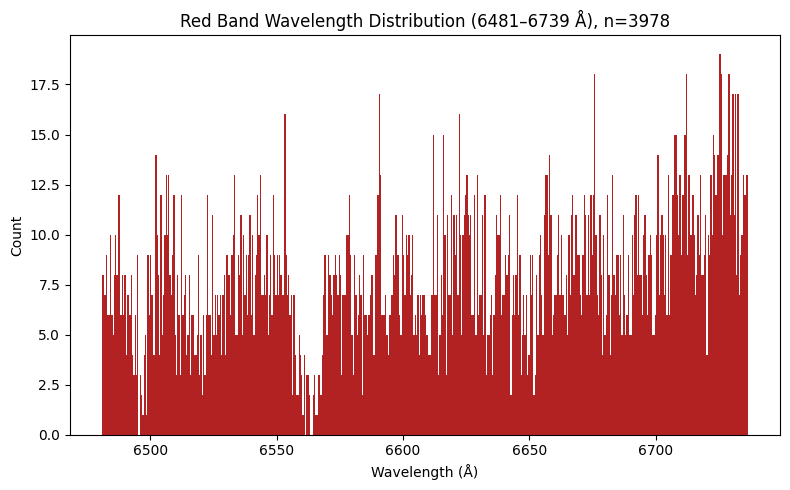

Red: 3978 detections in range
Red: 3978 total detections | bins ≥ 3 counts: 51


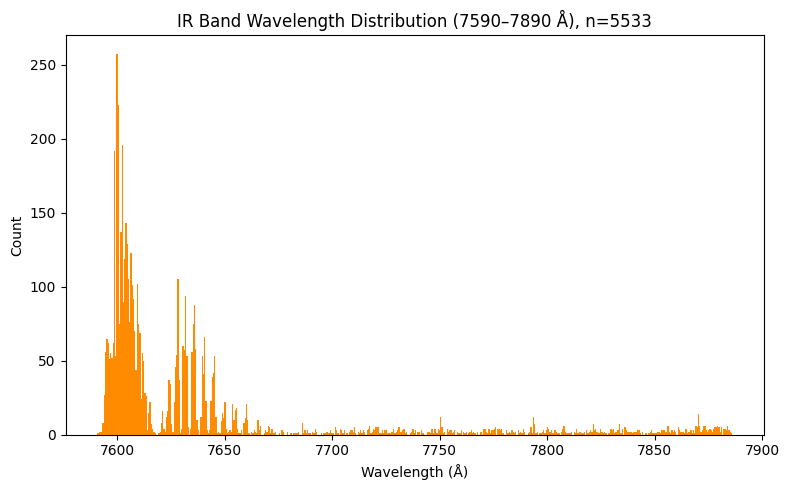

IR: 5533 detections in range
IR: 5533 total detections | bins ≥ 3 counts: 59


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the results
csv_path = "/datax/scratch/emmay/galah_spectra/detected_peaks/noninjected_detected_peaks.csv"
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} detected peaks")

# Define bands in Angstroms (converted from nm, 1 nm = 10 Å)
bands = {
    "Blue": (4718, 4903),
    "Green": (5649, 5873),
    "Red": (6481, 6739),
    "IR": (7590, 7890),
}

colors = {
    "Blue": "steelblue",
    "Green": "seagreen",
    "Red": "firebrick",
    "IR": "darkorange",
}

for band_name, (lam_min, lam_max) in bands.items():
    band_df = df[(df["peak_wavelength"] >= lam_min) & (df["peak_wavelength"] <= lam_max)]
    num_bins = int((lam_max - lam_min) / 5)

    counts, bin_edges = np.histogram(band_df["peak_wavelength"], bins=num_bins, range=(lam_min, lam_max))
    bins_above_threshold = np.sum(counts >= 3)

    plt.figure(figsize=(8, 5))
    plt.hist(band_df["peak_wavelength"], bins=500, color=colors[band_name])
    plt.xlabel("Wavelength (Å)")
    plt.ylabel("Count")
    plt.title(f"{band_name} Band Wavelength Distribution ({lam_min}–{lam_max} Å), n={len(band_df)}")
    plt.tight_layout()
    plt.show()

    print(f"{band_name}: {len(band_df)} detections in range")
    print(f"{band_name}: {len(band_df)} total detections | bins ≥ 3 counts: {bins_above_threshold}")

In [5]:
from astropy.table import Table

band_results = []

for band_name, (lam_min, lam_max) in bands.items():
    band_df = df[(df["peak_wavelength"] >= lam_min) & (df["peak_wavelength"] <= lam_max)]

    num_bins = int((lam_max - lam_min) / 2)
    counts, bin_edges = np.histogram(band_df["peak_wavelength"], bins=num_bins, range=(lam_min, lam_max))
    bins_above_threshold = int(np.sum(counts >= 3))

    band_results.append({
        "Band": band_name,
        #"λmin (Å)": lam_min,
        #"λmax (Å)": lam_max,
        #"Total Detections": len(band_df),
        "Total Bins": num_bins,
        "Number of Bins ≥ 3 counts": bins_above_threshold,
    })

table = Table(rows=band_results)
print(table)


 Band Total Bins Number of Bins ≥ 3 counts
----- ---------- -------------------------
 Blue         92                        92
Green        112                       112
  Red        129                       128
   IR        150                       139


In [11]:
min(df["peak_flux"])

1.0085655450820925

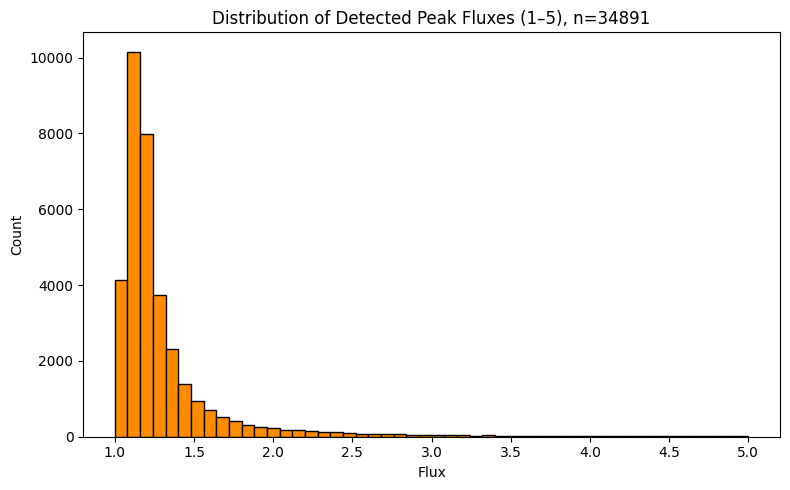


387 data points outside range (flux > 200):
         obj_id filt  peak_wavelength   peak_flux  peak_width
171027001601281    B      4770.271978    8.709127    0.199361
171027001601391    I      7862.634730    8.956074    0.139766
141104003301002    I      7640.492590   15.731018    0.345177
141104003301002    I      7875.507205    5.159743    0.332979
140711004401055    B      4778.322153 1119.258179    0.061521
140711004401055    B      4778.414155 2001.034546    0.104683
140711004401055    V      5732.151757   33.169262    0.147572
140711004401055    V      5844.262157   11.639936    0.204650
151009003101130    B      4828.325240   15.563694    0.206850
151009003101130    I      7765.980832    7.932725    0.357248
140813004601366    I      7601.360266    8.853073    0.131700
140813004601366    I      7797.536785   12.632924    0.204095
140813004601366    I      7797.904570   11.914864    0.146419
230801004501217    I      7600.771810    5.106655    0.182447
170805005101261    I     

In [13]:
# Histogram 2: Flux distribution (0–200 range)
flux_clipped = df["peak_flux"][(df["peak_flux"] >= 1) & (df["peak_flux"] <= 5)]
flux_outliers = df[df["peak_flux"] > 5]

plt.figure(figsize=(8, 5))
plt.hist(flux_clipped, bins=50, range=(1, 5), color="darkorange", edgecolor="black")
plt.xlabel("Flux")
plt.ylabel("Count")
plt.title(f"Distribution of Detected Peak Fluxes (1–5), n={len(flux_clipped)}")
plt.tight_layout()
plt.show()

print(f"\n{len(flux_outliers)} data points outside range (flux > 200):")
print(flux_outliers[["obj_id", "filt", "peak_wavelength", "peak_flux", "peak_width"]].to_string(index=False))

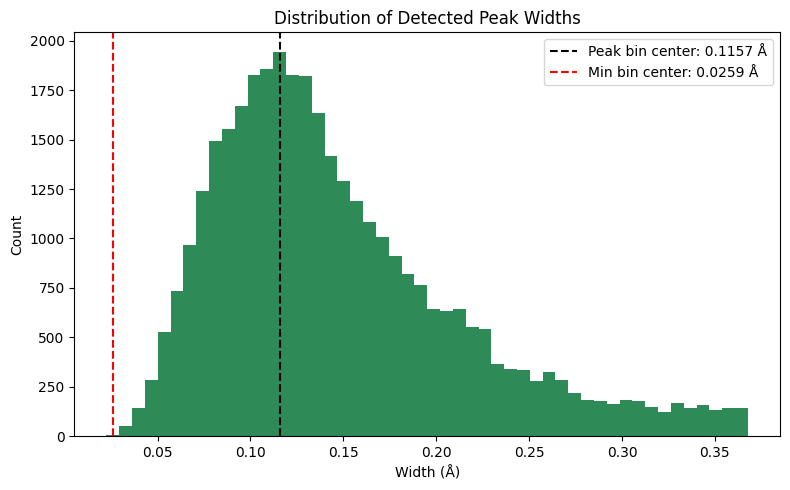

Peak bin range : 0.1123 – 0.1192 Å
Peak bin center: 0.1157 Å
Peak bin count : 1945

Min bin range  : 0.0225 – 0.0294 Å
Min bin center : 0.0259 Å
Min bin count  : 7


In [15]:
counts, bin_edges = np.histogram(df["peak_width"], bins=50)
peak_bin_idx = np.argmax(counts)
peak_bin_center = (bin_edges[peak_bin_idx] + bin_edges[peak_bin_idx + 1]) / 2
peak_bin_range = (bin_edges[peak_bin_idx], bin_edges[peak_bin_idx + 1])

min_bin_idx = np.argmax(counts >= 1)  # first True in the array = lowest bin with count >= 1
min_bin_center = (bin_edges[min_bin_idx] + bin_edges[min_bin_idx + 1]) / 2
min_bin_range = (bin_edges[min_bin_idx], bin_edges[min_bin_idx + 1])

plt.figure(figsize=(8, 5))
plt.stairs(counts, bin_edges, color="seagreen", fill=True)
plt.axvline(peak_bin_center, color='black', linestyle='--', linewidth=1.5, label=f"Peak bin center: {peak_bin_center:.4f} Å")
plt.axvline(min_bin_center, color='red', linestyle='--', linewidth=1.5, label=f"Min bin center: {min_bin_center:.4f} Å")
plt.xlabel("Width (Å)")
plt.ylabel("Count")
plt.title("Distribution of Detected Peak Widths")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Peak bin range : {peak_bin_range[0]:.4f} – {peak_bin_range[1]:.4f} Å")
print(f"Peak bin center: {peak_bin_center:.4f} Å")
print(f"Peak bin count : {counts[peak_bin_idx]}")
print(f"\nMin bin range  : {min_bin_range[0]:.4f} – {min_bin_range[1]:.4f} Å")
print(f"Min bin center : {min_bin_center:.4f} Å")
print(f"Min bin count  : {counts[min_bin_idx]}")

In [17]:
0.1157-0.0259+0.1157

0.2055

In [ ]:
import csv
from tqdm import tqdm

folder = "/datax/scratch/emmay/galah_spectra"
fits_files = [f for f in os.listdir(folder) if f.endswith(".fits")]

results = []
errors = []  # collect errors instead of printing them inline

for fits_file in tqdm(fits_files[:4000], desc="Detecting peaks"):
    filename_no_ext = fits_file[:-5]
    obj_id = filename_no_ext[:15]
    filt = filename_no_ext[16:]

    try:
        # Step 1: Read original spectrum (no injection)
        wave, flux = get_flux_wl(obj_id, filt, folder=folder)

        # Step 2: Try to detect peaks
        peak_wavelengths, peak_fluxes, widths = detect_laser_peak_with_fixed_level_width(
            wave, flux, height_fraction=0.15, y_level=1.0, max_pixel_width=5, plot=False
        )

        # Step 3: Save results for each detected peak
        for wl, fl, w in zip(peak_wavelengths, peak_fluxes, widths):
            results.append({
                "obj_id": obj_id,
                "filt": filt,
                "peak_wavelength": wl,
                "peak_flux": fl,
                "peak_width": w
            })

    except Exception as e:
        errors.append((fits_file, str(e)))
        print(str(e))

output_path = os.path.join(folder, "detected_peaks", "noninjected_detected_peaks.csv")
with open(output_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["obj_id", "filt", "peak_wavelength", "peak_flux", "peak_width"])
    writer.writeheader()
    writer.writerows(results)

print(f"Saved {len(results)} detected peaks to {output_path}")
if errors:
    print(f"{len(errors)} files failed (see `errors` list for details)")